# DocRED train 병합 + Re-DocRED 비교 EDA

> **최종 업데이트**: 2026-07-15
> 작성 요약: `train_annotated.json` + `train_distant.json`을 병합해 `train_merged.json`으로 저장(Part 1),
> 병합 train과 Re-DocRED `train_revised.json`의 분포 차이를 정규화(비율/밀도) 기준으로 비교하는 EDA를 수행(Part 2).

두 데이터셋은 문서 수가 약 34배 차이 나므로(병합 train ≈ 10.5만 vs Re-DocRED ≈ 3천),
**절대 빈도 비교는 하지 않고** 모든 비교를 비율(%) 또는 정규화 밀도(`density=True`) 기준으로 수행한다.


## Part 1. train 데이터 병합

`train_annotated.json`(사람이 직접 라벨링, 3,053 문서)과 `train_distant.json`(원거리 감독 자동 라벨,
약 101,873 문서, 417MB)을 하나의 문서 리스트로 병합해 `train_merged.json`으로 저장한다.
두 파일은 서로 다른 문서 집합이라 단순 concat으로 병합하면 된다.


## 1.1 준비 (경로 / 라이브러리)

In [1]:
import json
import os
import platform
import time
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = os.path.join("docred_data", "data")
TRAIN_ANNOTATED_PATH = os.path.join(DATA_DIR, "train_annotated.json")
TRAIN_DISTANT_PATH = os.path.join(DATA_DIR, "train_distant.json")
TRAIN_REVISED_PATH = os.path.join(DATA_DIR, "train_revised.json")
TRAIN_MERGED_PATH = os.path.join(DATA_DIR, "train_merged.json")
REL_INFO_PATH = os.path.join(DATA_DIR, "rel_info.json")

RANDOM_SEED = 42


한글 라벨이 그래프에 깨지지 않도록 폰트를 설정한다 (Windows 기준 `Malgun Gothic`).


In [2]:
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    # Linux는 한글 폰트가 기본 설치되어 있지 않을 수 있음 (필요 시 nanum 폰트 설치)
    pass
plt.rcParams["axes.unicode_minus"] = False


## 1.2 로드

`train_distant.json`은 417MB로 다른 split보다 훨씬 크다. 다만 로컬 RAM이 넉넉하면(16GB 이상)
`json.load`로 통째로 읽어도 메모리 문제가 없어 별도 스트리밍(`ijson`) 없이 진행한다.
RAM이 부족한 환경이라면 `ijson`으로 스트리밍 파싱하거나 필요한 필드만 추출하는 방식으로 바꿔야 한다.


In [3]:
t0 = time.time()
with open(TRAIN_ANNOTATED_PATH, encoding="utf-8") as f:
    train_annotated = json.load(f)
print(f"train_annotated: {len(train_annotated):,} docs  ({time.time() - t0:.1f}s)")

t0 = time.time()
with open(TRAIN_DISTANT_PATH, encoding="utf-8") as f:
    train_distant = json.load(f)
print(f"train_distant  : {len(train_distant):,} docs  ({time.time() - t0:.1f}s)")


train_annotated: 3,053 docs  (0.7s)


train_distant  : 101,873 docs  (25.4s)


## 1.3 병합 및 저장

두 문서 리스트를 단순 concat 한다 (서로 다른 문서 집합이라 중복 없음).

In [4]:
train_merged = train_annotated + train_distant
print(f"병합 후 문서 수: {len(train_merged):,}")


병합 후 문서 수: 104,926


In [5]:
t0 = time.time()
with open(TRAIN_MERGED_PATH, "w", encoding="utf-8") as f:
    json.dump(train_merged, f, ensure_ascii=False)
size_mb = os.path.getsize(TRAIN_MERGED_PATH) / 1e6
print(f"저장 완료: {TRAIN_MERGED_PATH}  ({time.time() - t0:.1f}s, {size_mb:.1f} MB)")


저장 완료: docred_data\data\train_merged.json  (95.3s, 448.9 MB)


## 1.4 검증

병합 후 문서 수와 총 트리플(relation label) 수를 확인한다.

In [6]:
n_docs = len(train_merged)
n_triples = sum(len(doc.get("labels", [])) for doc in train_merged)
print(f"문서 수      : {n_docs:,}")
print(f"총 트리플 수 : {n_triples:,}")


문서 수      : 104,926
총 트리플 수 : 1,543,818


## Part 2. 비교 EDA — 병합 train vs Re-DocRED train

Re-DocRED(`train_revised.json`)는 DocRED 원본의 **누락되거나 잘못된 라벨을 재정제한** 버전으로,
병합 train과 같은 3,053개 문서를 다루지만 라벨 품질이 다르다.

**주의: 병합 train(≈10.5만 문서)과 Re-DocRED(≈3천 문서)는 문서 수가 약 34배 차이난다.**
이 노트북의 모든 비교는 절대 빈도가 아니라 **정규화된 값(밀도 `density=True`, 비율 `%`)** 으로만 수행한다.


## 2.1 Re-DocRED 로드 + 관계명 매핑

In [7]:
with open(TRAIN_REVISED_PATH, encoding="utf-8") as f:
    train_revised = json.load(f)
print(f"train_revised (Re-DocRED): {len(train_revised):,} docs")

with open(REL_INFO_PATH, encoding="utf-8") as f:
    rel_info = json.load(f)
print(f"관계 종류 수: {len(rel_info)}")


train_revised (Re-DocRED): 3,053 docs
관계 종류 수: 96


## 2.2 요약 통계

문서 수, 총 트리플 수, 문서당 평균 트리플/엔티티/문장/토큰 수를 두 데이터셋에서 비교한다.


In [8]:
def doc_stats(doc):
    sents = doc["sents"]
    return {
        "title": doc["title"],
        "n_sents": len(sents),
        "n_tokens": sum(len(s) for s in sents),
        "n_entities": len(doc["vertexSet"]),
        "n_triples": len(doc.get("labels", [])),
    }


def build_stats_df(docs):
    return pd.DataFrame(doc_stats(d) for d in docs)


merged_stats = build_stats_df(train_merged)
revised_stats = build_stats_df(train_revised)


In [9]:
def summarize(name, docs, stats_df):
    return {
        "dataset": name,
        "문서 수": len(docs),
        "총 트리플 수": int(stats_df["n_triples"].sum()),
        "문서당 평균 트리플 수": stats_df["n_triples"].mean(),
        "문서당 평균 엔티티 수": stats_df["n_entities"].mean(),
        "문서당 평균 문장 수": stats_df["n_sents"].mean(),
        "문서당 평균 토큰 수": stats_df["n_tokens"].mean(),
    }


summary_df = pd.DataFrame(
    [
        summarize("병합 train (annotated+distant)", train_merged, merged_stats),
        summarize("Re-DocRED train_revised", train_revised, revised_stats),
    ]
).set_index("dataset")
summary_df.round(2)


,문서 수,총 트리플 수,문서당 평균 트리플 수,문서당 평균 엔티티 수,문서당 평균 문장 수,문서당 평균 토큰 수
dataset,,,,,,
병합 train (annotated+distant),104926,1543818,14.71,19.30,8.12,199.50
Re-DocRED train_revised,3053,85932,28.15,19.44,7.94,197.66


## 2.3 문서당 트리플 수 분포

`density=True`로 정규화한 히스토그램을 겹쳐 그린다. 상위 1% 이상치는 시각화 가독성을 위해 축에서 제외한다
(집계 통계에는 그대로 포함됨).


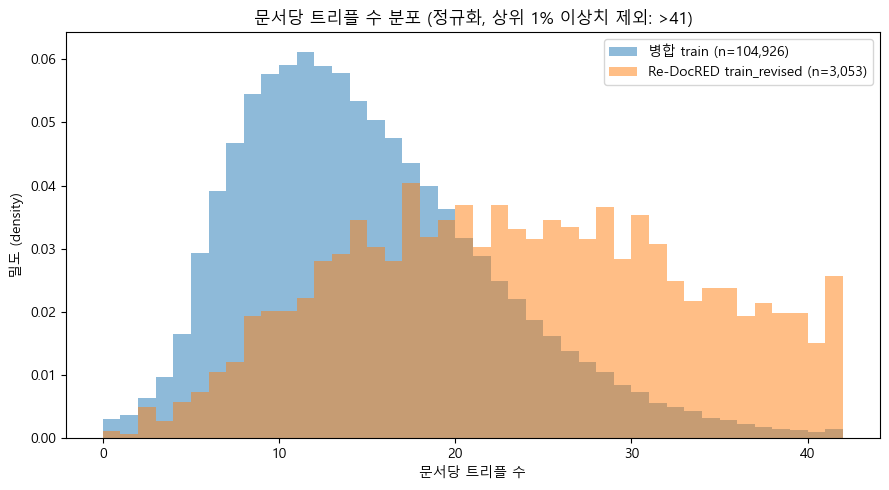

In [10]:
clip = int(pd.concat([merged_stats["n_triples"], revised_stats["n_triples"]]).quantile(0.99))
bins = range(0, clip + 2, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(merged_stats["n_triples"], bins=bins, density=True, alpha=0.5,
        label=f"병합 train (n={len(train_merged):,})")
ax.hist(revised_stats["n_triples"], bins=bins, density=True, alpha=0.5,
        label=f"Re-DocRED train_revised (n={len(train_revised):,})")
ax.set_title(f"문서당 트리플 수 분포 (정규화, 상위 1% 이상치 제외: >{clip})")
ax.set_xlabel("문서당 트리플 수")
ax.set_ylabel("밀도 (density)")
ax.legend()
plt.tight_layout()
plt.show()


## 2.4 관계 라벨(r) 분포 비교

각 데이터셋에서 관계 종류별 비율(%)을 계산하고, **병합 train 기준 상위 20개 관계**에 대해
두 데이터셋을 나란히 막대그래프로 비교한다.


In [11]:
def relation_pct(docs):
    counter = Counter(lab["r"] for doc in docs for lab in doc.get("labels", []))
    total = sum(counter.values())
    return pd.Series({r: c / total * 100 for r, c in counter.items()})


merged_rel_pct = relation_pct(train_merged)
revised_rel_pct = relation_pct(train_revised)

top20_rels = merged_rel_pct.sort_values(ascending=False).head(20).index
compare_df = pd.DataFrame(
    {
        "병합 train": merged_rel_pct.reindex(top20_rels).fillna(0),
        "Re-DocRED train_revised": revised_rel_pct.reindex(top20_rels).fillna(0),
    }
)
compare_df.index = [rel_info.get(r, r) for r in compare_df.index]
compare_df


,병합 train,Re-DocRED train_revised
country,20.914512,16.758600
located in the administrative territorial entity,9.534738,23.742029
country of citizenship,8.359081,5.428711
contains administrative territorial entity,4.187670,3.920542
publication date,2.505477,1.886375
country of origin,2.368673,1.103198
date of birth,2.269827,1.363869
capital,2.210882,0.207141
place of birth,2.056136,0.805288
capital of,1.936239,0.207141


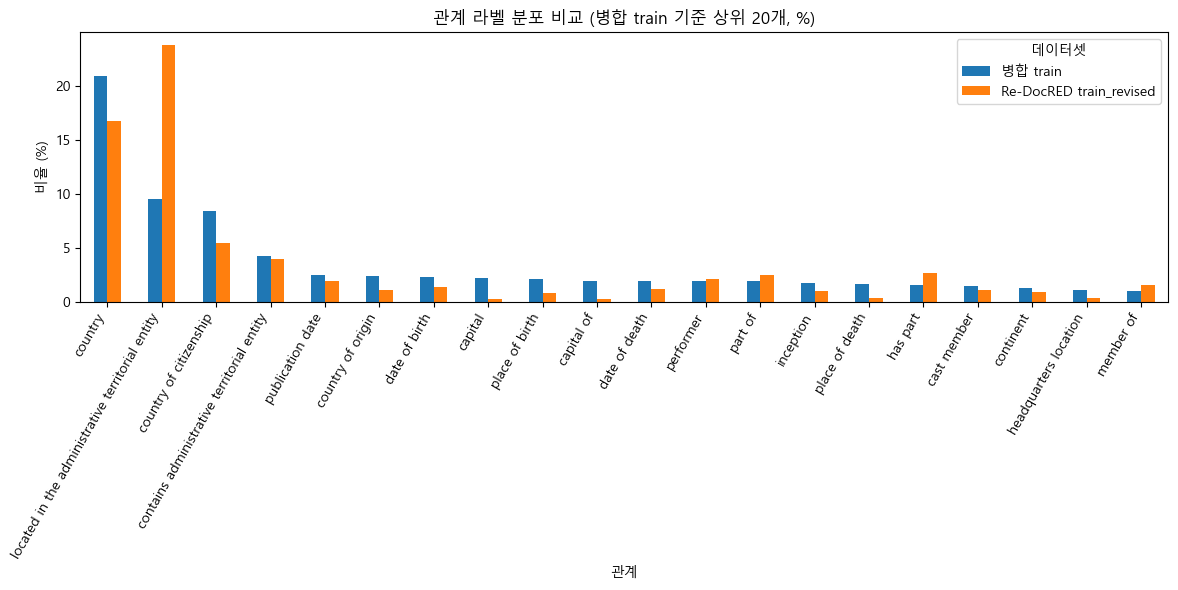

In [12]:
ax = compare_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("관계 라벨 분포 비교 (병합 train 기준 상위 20개, %)")
ax.set_xlabel("관계")
ax.set_ylabel("비율 (%)")
ax.legend(title="데이터셋")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


## 2.5 Evidence 분석

트리플(relation label)마다 붙어있는 `evidence`(근거 문장 인덱스) 개수의 분포와,
evidence가 비어 있는 트리플의 비율을 비교한다.

**참고**: `train_distant`는 원거리 감독(distant supervision)으로 자동 생성된 라벨이라 evidence의
신뢰도가 낮다. DREEAM처럼 evidence loss를 함께 학습하는 모델을 병합 train으로 학습할 경우,
distant 문서 비중이 커서(≈97%) evidence 품질 저하가 evidence loss 학습에 부정적 영향을 줄 수 있다는 점을
유의해야 한다.


In [13]:
def evidence_stats(docs):
    counts = []
    empty = 0
    total = 0
    for doc in docs:
        for lab in doc.get("labels", []):
            n_evi = len(lab.get("evidence", []))
            counts.append(n_evi)
            total += 1
            if n_evi == 0:
                empty += 1
    empty_pct = empty / total * 100 if total else 0.0
    return pd.Series(counts, name="n_evidence"), empty_pct


merged_evi, merged_empty_pct = evidence_stats(train_merged)
revised_evi, revised_empty_pct = evidence_stats(train_revised)

print(f"병합 train      : evidence 비어있는 트리플 비율 = {merged_empty_pct:.2f}%")
print(f"Re-DocRED revised: evidence 비어있는 트리플 비율 = {revised_empty_pct:.2f}%")


병합 train      : evidence 비어있는 트리플 비율 = 97.62%
Re-DocRED revised: evidence 비어있는 트리플 비율 = 45.00%


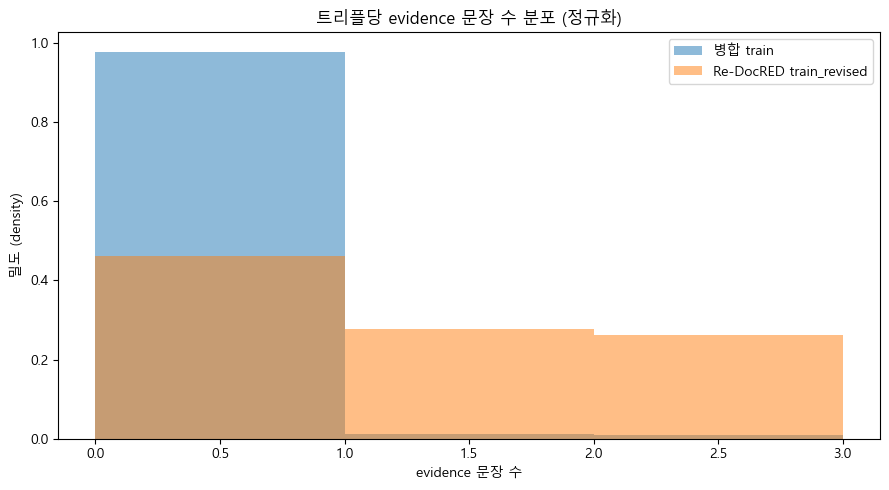

In [14]:
clip = int(pd.concat([merged_evi, revised_evi]).quantile(0.99))
bins = range(0, max(clip, 1) + 2, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(merged_evi, bins=bins, density=True, alpha=0.5, label="병합 train")
ax.hist(revised_evi, bins=bins, density=True, alpha=0.5, label="Re-DocRED train_revised")
ax.set_title("트리플당 evidence 문장 수 분포 (정규화)")
ax.set_xlabel("evidence 문장 수")
ax.set_ylabel("밀도 (density)")
ax.legend()
plt.tight_layout()
plt.show()


## 2.6 문서 길이 분포 (문장 수 / 토큰 수)

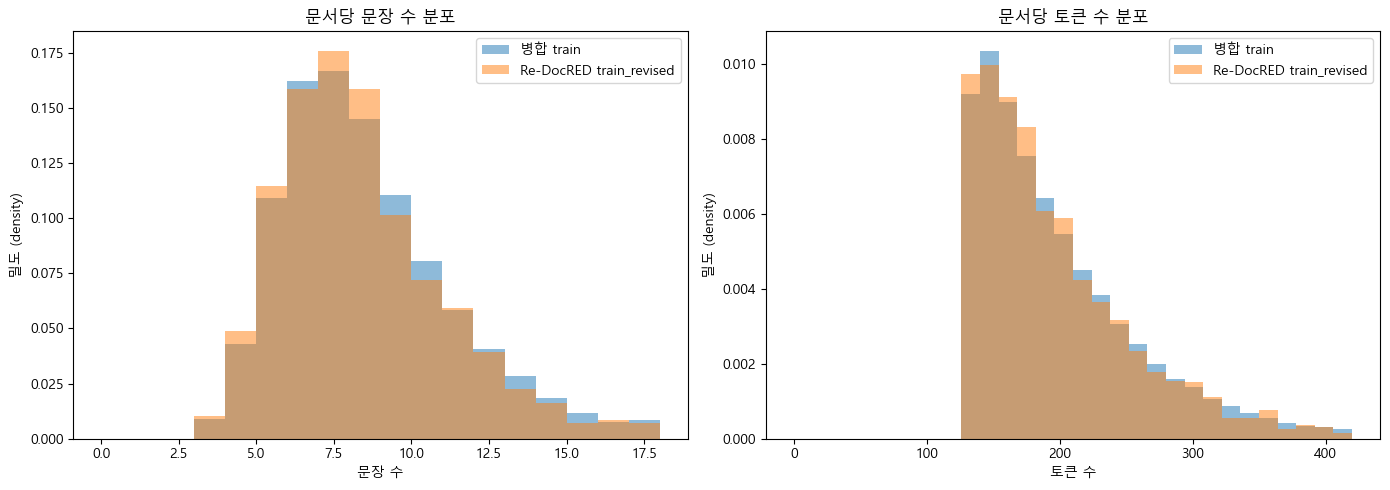

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

s_clip = int(pd.concat([merged_stats["n_sents"], revised_stats["n_sents"]]).quantile(0.99))
s_bins = range(0, s_clip + 2, 1)
axes[0].hist(merged_stats["n_sents"], bins=s_bins, density=True, alpha=0.5, label="병합 train")
axes[0].hist(revised_stats["n_sents"], bins=s_bins, density=True, alpha=0.5, label="Re-DocRED train_revised")
axes[0].set_title("문서당 문장 수 분포")
axes[0].set_xlabel("문장 수")
axes[0].set_ylabel("밀도 (density)")
axes[0].legend()

t_clip = int(pd.concat([merged_stats["n_tokens"], revised_stats["n_tokens"]]).quantile(0.99))
axes[1].hist(merged_stats["n_tokens"], bins=30, range=(0, t_clip), density=True, alpha=0.5, label="병합 train")
axes[1].hist(revised_stats["n_tokens"], bins=30, range=(0, t_clip), density=True, alpha=0.5, label="Re-DocRED train_revised")
axes[1].set_title("문서당 토큰 수 분포")
axes[1].set_xlabel("토큰 수")
axes[1].set_ylabel("밀도 (density)")
axes[1].legend()

plt.tight_layout()
plt.show()


## 2.7 결론

**주요 수치 (2026-07-15 실행 결과)**

| | 병합 train | Re-DocRED revised |
|---|---|---|
| 문서 수 | 104,926 | 3,053 |
| 총 트리플 수 | 1,543,818 | 85,932 |
| 문서당 평균 트리플 수 | 14.71 | **28.15** |
| 문서당 평균 엔티티 수 | 19.30 | 19.44 |
| evidence 비어있는 트리플 비율 | **97.62%** | 45.00% |

- **트리플 밀도가 오히려 역전됨**: 병합 train은 문서 수가 34배 많지만, 문서당 평균 트리플 수는
  Re-DocRED가 거의 2배(28.15 vs 14.71) 더 높다. Re-DocRED가 원본 DocRED의 **누락된 라벨(false negative)을
  대거 보완**했기 때문으로, distant 문서가 절대다수인 병합 train은 트리플이 훨씬 희소하다는 뜻이다.
- **관계 분포 편향**: 병합 train 상위 1위 관계는 `country`(20.9%)인 반면, Re-DocRED에서는
  `located in the administrative territorial entity`가 1위(23.7%, 병합 train에서는 9.5%로 2위)로 순위가
  뒤바뀐다. distant supervision이 특정 관계(`country`, `country of citizenship` 등 고빈도 위키데이터 관계)에
  편향되어 라벨링되었을 가능성을 보여준다.
- **Evidence 신뢰도 격차가 실제로 매우 크다**: 병합 train은 트리플의 **97.62%**가 evidence가 비어 있는 반면
  Re-DocRED는 45.00%다. distant 문서가 병합 train의 절대다수(≈97%)를 차지하므로 이 차이는 사실상
  distant supervision의 evidence 부재 문제를 그대로 반영한다. **DREEAM처럼 evidence loss를 함께 학습하는
  모델을 병합 train으로 학습하면, 트리플의 대부분에 evidence 라벨이 없어 evidence loss 학습 신호가 거의
  주어지지 않는다는 뜻이므로 반드시 주의해야 한다.**
- **학습 데이터 선택 시사점**:
  - relation classification만 목표라면 병합 train(대규모)이 recall 확보에 유리할 수 있으나, 관계 분포
    편향과 라벨 노이즈(distant supervision 특유의 false positive/negative)를 감안해야 한다.
  - evidence-aware 학습(DREEAM 등)이나 높은 라벨 정확도가 중요한 경우, evidence가 절반 이상 채워져 있고
    트리플 밀도도 높은 **Re-DocRED(`train_revised`) 또는 `train_annotated`만 사용하는 편이 안전**하다.
  - 절충안으로 distant(병합 train)로 사전학습 후 Re-DocRED로 파인튜닝하는 2단계 전략을 고려할 수 있다.
